## Aprendizaje no supervisado 

Autores:
Jeremias Jiret Padilla Guerrero
Camilo Andres Martinez Diaz
Rafael Alfonso Reales Sajaud
Genaro Gómez Ruiz


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')

In [4]:
dataset = pd.read_csv("Mall_Customers.csv")
dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
data = dataset.drop(['CustomerID', 'Gender'], axis=1)

In [8]:
data.isna().sum()

Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [10]:
data.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


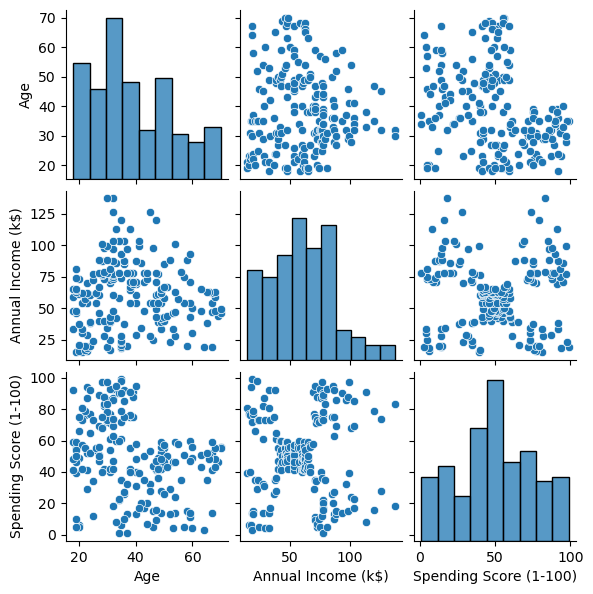

In [12]:
sns.pairplot(data, height=2, kind='scatter')

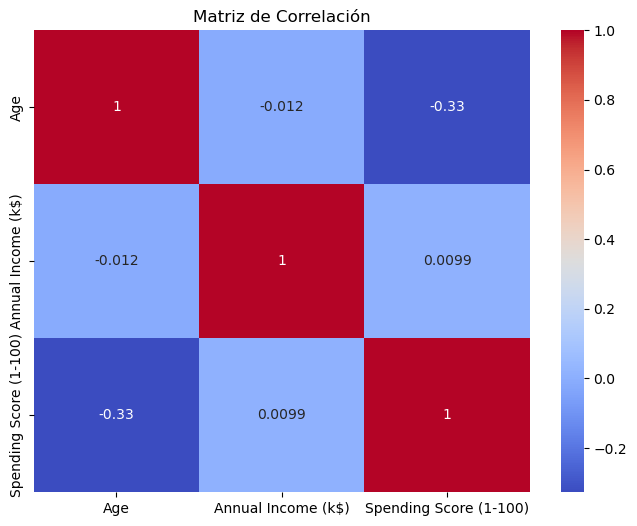

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

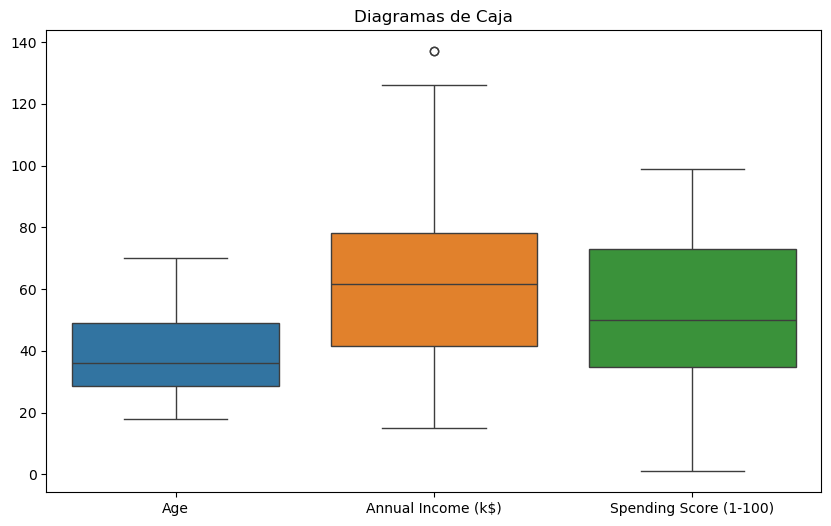

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data)
plt.title('Diagramas de Caja')
plt.show()

In [18]:
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)

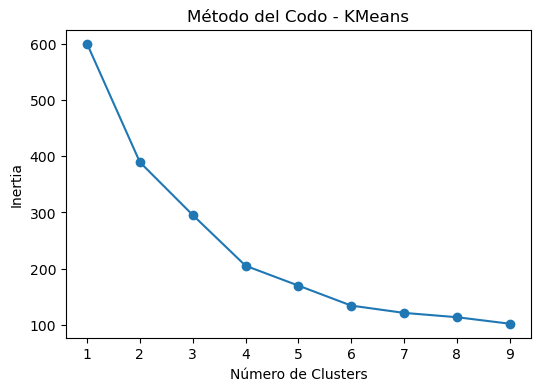

In [20]:
Nc = range(1, 10)
kmeans_models = [KMeans(n_clusters=i, random_state=42).fit(X) for i in Nc]
scores = [model.inertia_ for model in kmeans_models]

plt.figure(figsize=(6,4))
plt.plot(Nc, scores, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Inertia')
plt.title('Método del Codo - KMeans')
plt.show()

In [22]:
Nc = range(2, 10)
silhouette_scores = []
calinski_scores = []
davies_scores = []

for k in Nc:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    labels = kmeans.labels_
    silhouette_scores.append(silhouette_score(X, labels))
    calinski_scores.append(calinski_harabasz_score(X, labels))
    davies_scores.append(davies_bouldin_score(X, labels))

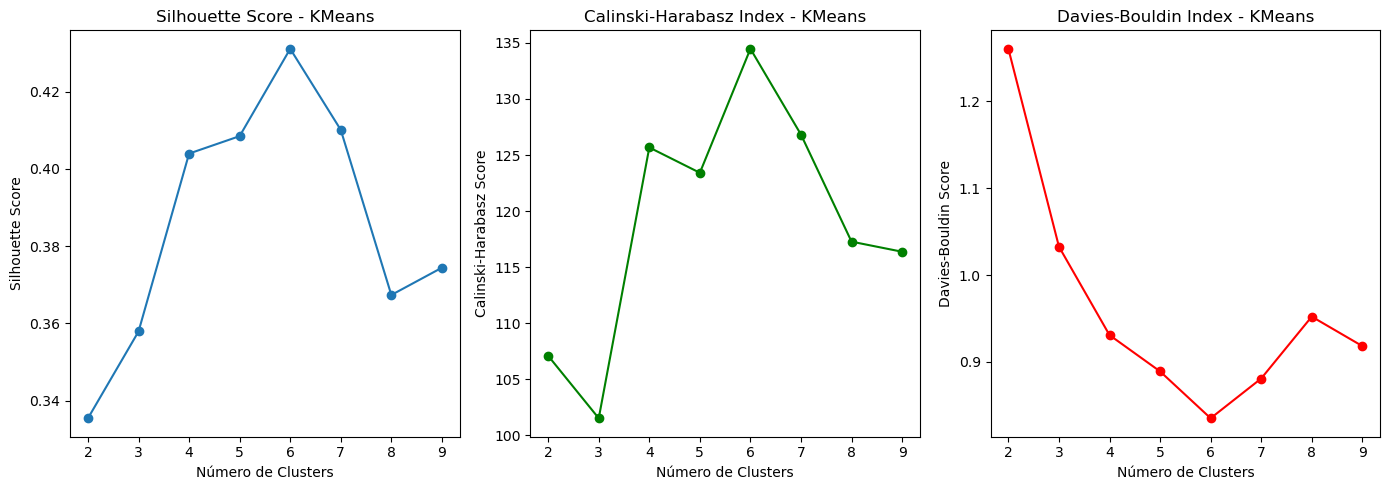

In [24]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(Nc, silhouette_scores, marker='o')
plt.title('Silhouette Score - KMeans')
plt.xlabel('Número de Clusters')
plt.ylabel('Silhouette Score')

plt.subplot(1, 3, 2)
plt.plot(Nc, calinski_scores, marker='o', color='green')
plt.title('Calinski-Harabasz Index - KMeans')
plt.xlabel('Número de Clusters')
plt.ylabel('Calinski-Harabasz Score')

plt.subplot(1, 3, 3)
plt.plot(Nc, davies_scores, marker='o', color='red')
plt.title('Davies-Bouldin Index - KMeans')
plt.xlabel('Número de Clusters')
plt.ylabel('Davies-Bouldin Score')

plt.tight_layout()
plt.show()


In [26]:
kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

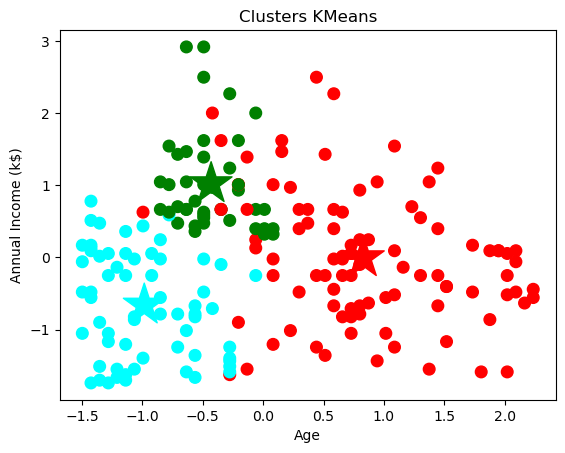

In [28]:
colores = ['red', 'green', 'cyan']
asignar = [colores[label] for label in labels]

f1 = X['Age'].values
f2 = X['Annual Income (k$)'].values
plt.scatter(f1, f2, c=asignar, s=70)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', c=colores, s=1000)
plt.title('Clusters KMeans')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show()

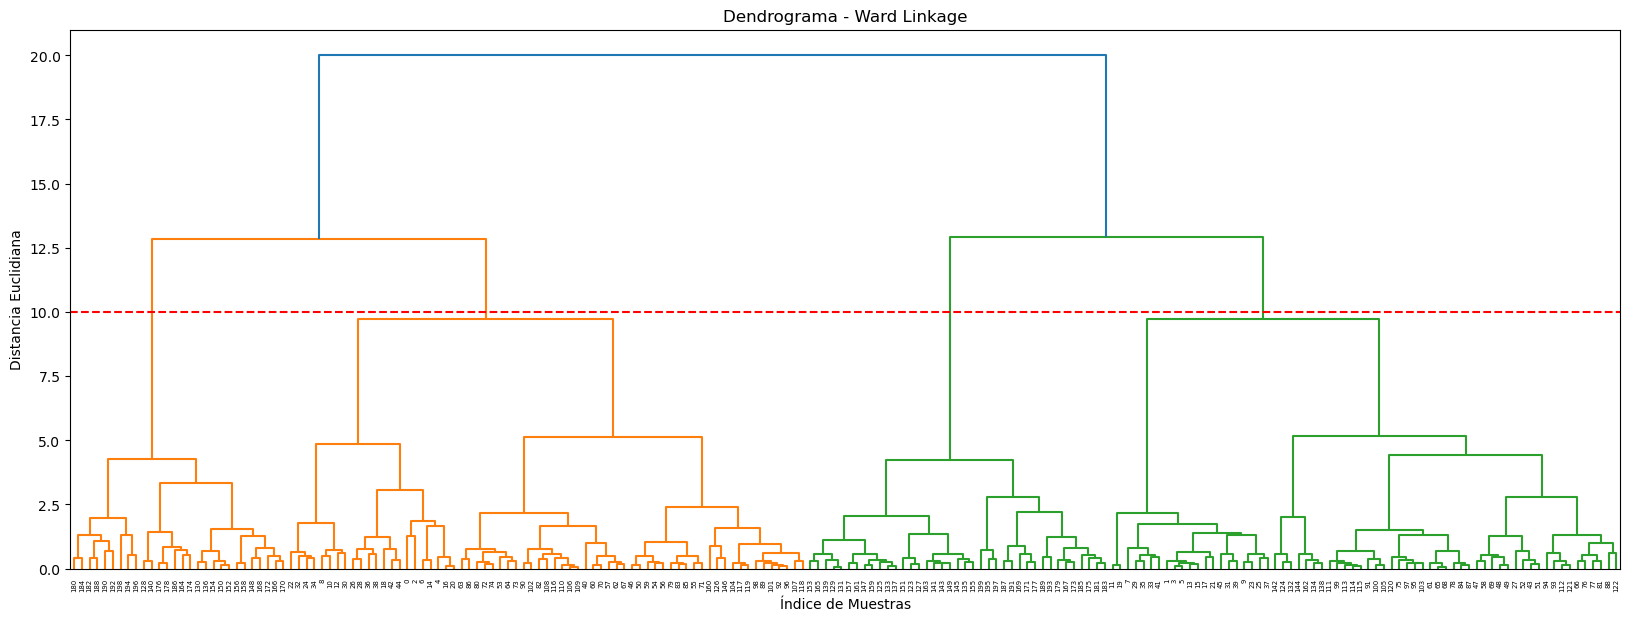

In [30]:
ward_clustering = linkage(X, method="ward")
plt.figure(figsize=(20, 7))
dendrogram(ward_clustering)
plt.axhline(y=10, color='r', linestyle='--')
plt.title('Dendrograma - Ward Linkage')
plt.xlabel('Índice de Muestras')
plt.ylabel('Distancia Euclidiana')
plt.show()

In [32]:
range_n_clusters = range(2, 10)
silhouette_scores_hier = []
calinski_scores_hier = []
davies_scores_hier = []

for n_clusters in range_n_clusters:
    hier = AgglomerativeClustering(n_clusters=n_clusters)
    labels_hier = hier.fit_predict(X)
    silhouette_scores_hier.append(silhouette_score(X, labels_hier))
    calinski_scores_hier.append(calinski_harabasz_score(X, labels_hier))
    davies_scores_hier.append(davies_bouldin_score(X, labels_hier))

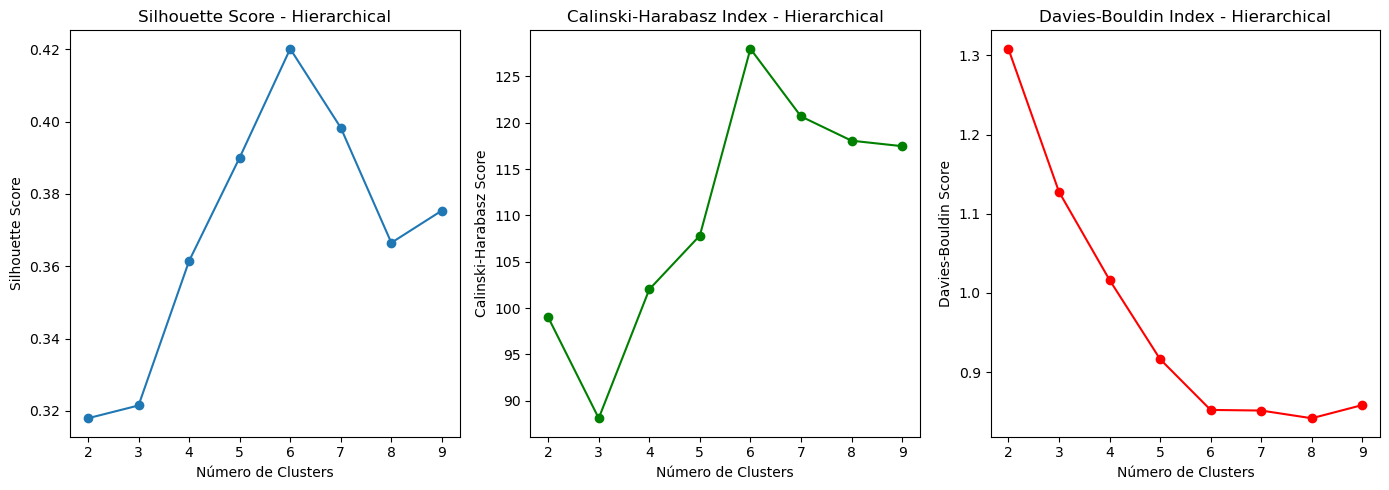

In [34]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(range_n_clusters, silhouette_scores_hier, marker='o')
plt.title('Silhouette Score - Hierarchical')
plt.xlabel('Número de Clusters')
plt.ylabel('Silhouette Score')

plt.subplot(1, 3, 2)
plt.plot(range_n_clusters, calinski_scores_hier, marker='o', color='green')
plt.title('Calinski-Harabasz Index - Hierarchical')
plt.xlabel('Número de Clusters')
plt.ylabel('Calinski-Harabasz Score')

plt.subplot(1, 3, 3)
plt.plot(range_n_clusters, davies_scores_hier, marker='o', color='red')
plt.title('Davies-Bouldin Index - Hierarchical')
plt.xlabel('Número de Clusters')
plt.ylabel('Davies-Bouldin Score')

plt.tight_layout()
plt.show()

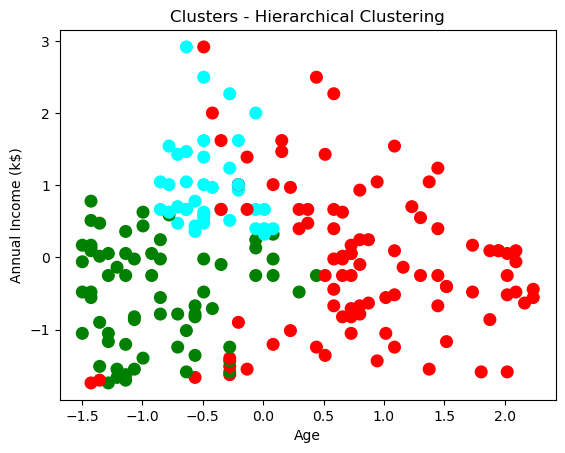

In [36]:
hier_clustering = AgglomerativeClustering(n_clusters=3)
labels_hier = hier_clustering.fit_predict(X)

# Gráfica de clusters jerárquicos
colores = ['red', 'green', 'cyan']
asignar = [colores[label] for label in labels_hier]

f1 = X['Age'].values
f2 = X['Annual Income (k$)'].values
plt.scatter(f1, f2, c=asignar, s=70)
plt.title('Clusters - Hierarchical Clustering')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show()

In [38]:
X_dist = pdist(X)
Z = linkage(X, 'ward')
coph_corr, _ = cophenet(Z, X_dist)
print("Coeficiente de correlación cofenética:", coph_corr)

Coeficiente de correlación cofenética: 0.6261774947075186


# 